# 03 - Backtest Results

Evaluate the Maximum Sharpe Ratio portfolio out-of-sample with monthly rebalancing, and compare against the S&P 500 benchmark.

In [1]:
import sys, os
sys.path.insert(0, '../src')
import yaml
import pandas as pd
import numpy as np

from data_loader import compute_monthly_returns, compute_stats
from optimization import gmv_portfolio, max_sharpe_portfolio, portfolio_performance
from backtest import backtest_fixed_weights, summarize_performance
from visualization import plot_cumulative_returns

In [2]:
with open('../configs/tickers.yaml') as f:
    tickers = yaml.safe_load(f)['tickers']
with open('../configs/params.yaml') as f:
    params = yaml.safe_load(f)

prices = pd.read_csv('../data/stock_prices.csv', index_col=0, parse_dates=True)
monthly_returns = compute_monthly_returns(prices[tickers])
mean_returns, cov_matrix = compute_stats(monthly_returns)

msr_w, msr_ret, msr_vol, msr_sharpe = max_sharpe_portfolio(
    mean_returns.values, cov_matrix.values, params['risk_free_rate']
)

## Run the out-of-sample backtest

Weights are fixed at their in-sample MSR values and the portfolio is rebalanced back to these weights every month.

Saved plot to ../results/cumulative_returns.png


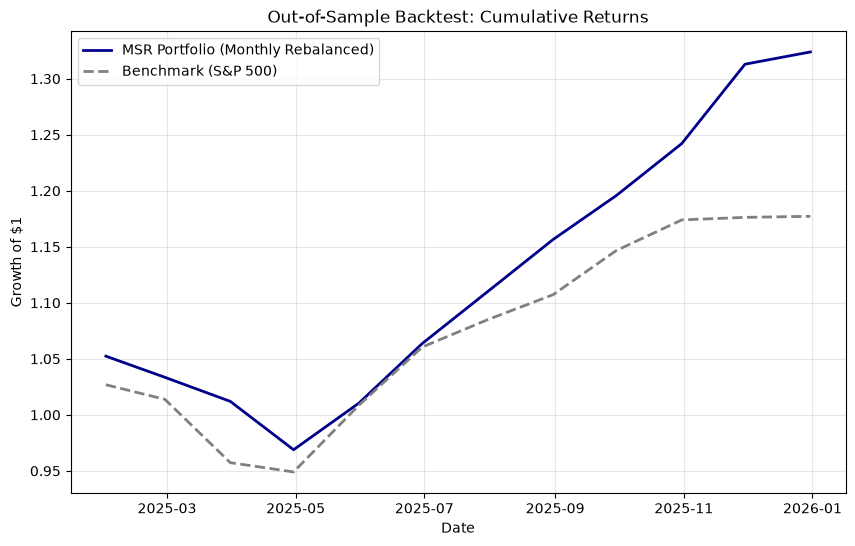

In [3]:
port_cum, port_monthly = backtest_fixed_weights(
    monthly_returns, msr_w, params['backtest_start']
)

bench_monthly = prices[[params['benchmark_ticker']]].resample('ME').last().pct_change().dropna()
bench_oos = bench_monthly.loc[bench_monthly.index >= params['backtest_start']][params['benchmark_ticker']]
bench_cum = (1 + bench_oos).cumprod()

fig = plot_cumulative_returns(port_cum, bench_cum, save_path='../results/cumulative_returns.png')

## Performance metrics

In [4]:
port_summary = summarize_performance('MSR Portfolio (OOS Backtest)', port_monthly, params['risk_free_rate'])
bench_summary = summarize_performance('Benchmark (S&P 500)', bench_oos, params['risk_free_rate'])

full_summary = port_summary + '\n\n' + bench_summary
print(full_summary)

with open('../results/performance_summary.txt', 'w') as f:
    f.write(full_summary)

--- MSR Portfolio (OOS Backtest) ---
Annualized Return: 33.20%
Annualized Volatility: 11.70%
Sharpe Ratio: 2.45
Max Drawdown: -7.94%

--- Benchmark (S&P 500) ---
Annualized Return: 18.36%
Annualized Volatility: 10.98%
Sharpe Ratio: 1.26
Max Drawdown: -7.58%


## Takeaways

- The MSR portfolio's realized out-of-sample Sharpe ratio can be compared directly to the benchmark's.
- A large gap between in-sample expected Sharpe and out-of-sample realized Sharpe illustrates a core limitation of mean-variance optimization: **sensitivity to estimation error** in expected returns.